# Домашнее задание «Функции потерь и оптимизация»

В работе нужно:

1. Реализовать три функции потерь и вручную посчитать их градиенты на простом примере.
2. Применить градиентный спуск с фиксированным шагом для минимизации квадратичной функции и показать, как на него влияет скорость обучения.
3. Сравнить полный градиентный спуск и стохастический градиентный спуск на задаче линейной регрессии.
4. Обучить логистическую регрессию с оптимизаторами `SGD` и `Adam` и сравнить их поведение.
5. Сделать итоговый вывод о выборе оптимизатора в нескольких сценариях.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

### 1. Реализация функции потерь и ручной расчёт градиентов

Используйте заданные массивы:

* Для MSE и MAE:
    * `y_true = [1.0, 0.0, 2.0]`
    * `y_pred = [0.8, 0.4, 1.5]`

* Для бинарной кросс-энтропии:
    * `y_true = [1, 0, 1, 0]`
    * `y_pred = [0.9, 0.3, 0.6, 0.2]`

Необходимо:
* Реализовать функции:
    * MSE
    * MAE - Для MAE реализуйте субградиент по предсказаниям. Если ошибка равна 0, можно считать субградиент равным 0.
    * Binary Cross-Entropy - Для Binary Cross-Entropy посчитайте градиент по предсказанным вероятностям y_pred.

* Для каждой функции:
    * посчитать значение функции потерь;
    * вручную реализовать градиент по предсказаниям;
    * вывести полученные значения.

* Коротко прокомментировать:
    * чем отличается поведение MSE и MAE;
    * почему для бинарной классификации обычно используют бинарную кросс-энтропию.

In [ ]:
# данные для MSE и MAE:
y_true_regr = np.array([1.0, 0.0, 2.0])
y_pred_regr = np.array([0.8, 0.4, 1.5])
# данные для бинарной кросс-энтропии:
y_true_bin = np.array([1, 0, 1, 0])
y_pred_bin = np.array([0.9, 0.3, 0.6, 0.2])

# упаковка массивов в кортежи для удобства последующих вызовов функций
regr_data = (y_true_regr, y_pred_regr)
bin_data = (y_true_bin, y_pred_bin)

# реализация функций вычисления функций потерь, градиентов, бинарной кросс-энтропии

def mse_loss(y_true, y_pred):
    '''Вычисляет среднеквадратичную ошибку'''
    return np.mean((y_true - y_pred) ** 2)

def mse_gradient(y_true, y_pred):
    '''Вычисляет градиент MSE по предсказаниям y_pred'''
    n = len(y_true)
    return 2 * (y_pred - y_true) / n

def mae_loss(y_true, y_pred):
    '''Вычисляет среднюю абсолютную ошибку'''
    return np.mean(np.abs(y_true - y_pred))

def mae_gradient(y_true, y_pred):
    '''Вычисляет субградиент MAE по предсказаниям y_pred'''
    n = len(y_true)
    return np.sign(y_pred - y_true) / n

def binary_cross_entropy(y_true, y_pred):
    '''Вычисляет бинарную кросс-энтропию.'''
    # ограничение предсказанных вероятностей для избежания вычисления log(0).
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    return -np.mean(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )

def binary_cross_entropy_gradient(y_true, y_pred):
    '''Вычисляет градиент бинарной кросс-энтропии по вероятностям y_pred.'''
    n = len(y_true)

    # ограничение предсказанных вероятностей для избежания вычисления log(0).
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    return (
        -y_true / y_pred
        + (1 - y_true) / (1 - y_pred)
    ) / n

# расчет значений функций потерь и градиентов
# MSE
mse_value = mse_loss(*regr_data)
mse_grad_values = mse_gradient(*regr_data)

# MAE
mae_value = mae_loss(*regr_data)
mae_grad_values = mae_gradient(*regr_data)

# Binary Cross-Entropy
bce_value = binary_cross_entropy(*bin_data)
bce_grad_values = binary_cross_entropy_gradient(*bin_data)

print('Результаты расчета функций потерь и градиентов:\n')
print('MSE')
print(f'Loss: {mse_value:.4f}')
print(f'Gradient: {mse_grad_values}')
print('\nMAE')
print(f'Loss: {mae_value:.4f}')
print(f'Gradient: {mae_grad_values}')
print('\nBinary cross-entropy')
print(f'Loss: {bce_value:.4f}')
print(f'Gradient: {bce_grad_values}')

Результаты расчета функций потерь и градиентов:

MSE
Loss: 0.1500
Gradient: [-0.13333333  0.26666667 -0.33333333]

MAE
Loss: 0.3667
Gradient: [-0.33333333  0.33333333 -0.33333333]

Binary cross-entropy
Loss: 0.2990
Gradient: [-0.27777778  0.35714286 -0.41666667  0.3125    ]


Различие поведения `MSE` и `MAE` выражается в том, что они по-разному реагируют на величину ошибки. В `MSE` ошибка возводится в квадрат, следовательно, большие отклонения штрафуются сильнее, а модуль градиента увеличивается вместе с ошибкой. В `MAE` используется абсолютное отклонение, поэтому субградиент почти не зависит от величины ошибки и по модулю остаётся постоянным, из-за чего `MAE` менее чувствительна к выбросам.

`Binary Cross-Entropy` обычно используют в бинарной классификации, потому что она напрямую оценивает качество предсказанных вероятностей и сильнее штрафует уверенные неправильные предсказания.

### 2. Применение градиентного спуска к квадратичной функции и проверка влияния learning rate

Используйте заданные:
* Функцию
    * `f(x, y) = x² + 5y²`
* Градиент функции:
    * `∇f(x, y) = (2x, 10y)`
* Стартовую точку:
    * `(x0, y0) = (4, 4)`

Что нужно сделать:

* Реализовать градиентный спуск с фиксированным шагом.
* Запустить его из заданной стартовой точки.
* Сохранить траекторию движения точек по итерациям.
* Построить:
    * график значения функции по итерациям;
    * линии уровня функции;
    * траекторию движения алгоритма на плоскости.
* Повторить эксперимент для нескольких значений learning rate, например:
    * 0.01
    * 0.1
    * 0.3

In [ ]:
# исходные данные
# заданная квадратичная функция
def f(x):
    return x[0] ** 2 + 5 * x[1] ** 2

# градиент заданной функции
def gradf(x):
    return np.array([2 * x[0], 10 * x[1]])

# стартовая точка
x0 = np.array([4.0, 4.0])

# количество итераций принимаем равным
n_iter = 30

# значения learning rate (шага) для эксперимента
learning_rates = [0.01, 0.1, 0.3]

In [ ]:
# функция градиентного спуска с фиксированным шагом
def gradient_descent(f, gradf, x0, learning_rate, n_iter):
    '''Реализует градиентный спуск с фиксированным шагом'''
    x = x0.copy()

    trajectory = []
    loss_history = []

    trajectory.append(x.copy())
    loss_history.append(f(x))

    for _ in range(n_iter):
        gradient = gradf(x)
        x = x - learning_rate * gradient
        trajectory.append(x.copy())
        loss_history.append(f(x))

    return np.array(trajectory), np.array(loss_history)

In [ ]:
# проведение эксперимента
results = {}

for rate in learning_rates:
    trajectory, loss_history = gradient_descent(f, gradf, x0, rate, n_iter)
    results[rate] = {
        'trajectory': trajectory,
        'loss_history': loss_history
        }

    print(f'Шаг {rate}')
    print(f'Финальная точка: {trajectory[-1]}')
    print(f'Финальное значение функции: {loss_history[-1]:.6f}\n')

Шаг 0.01
Финальная точка: [2.18193728 0.16956463]
Финальное значение функции: 4.904611

Шаг 0.1
Финальная точка: [0.00495176 0.        ]
Финальное значение функции: 0.000025

Шаг 0.3
Финальная точка: [4.61168602e-12 4.29496730e+09]
Финальное значение функции: 92233720368547758080.000000



*Ось Y - значения функции f(x, y) - будет построена в логаримфической шкале для корректного отображения и сравнения поведения всех трех графиков. В обычной шкале из-за очень больших значений функции при шаге 0.3 остальные два графика отобразились бы буквально по оси Х.*

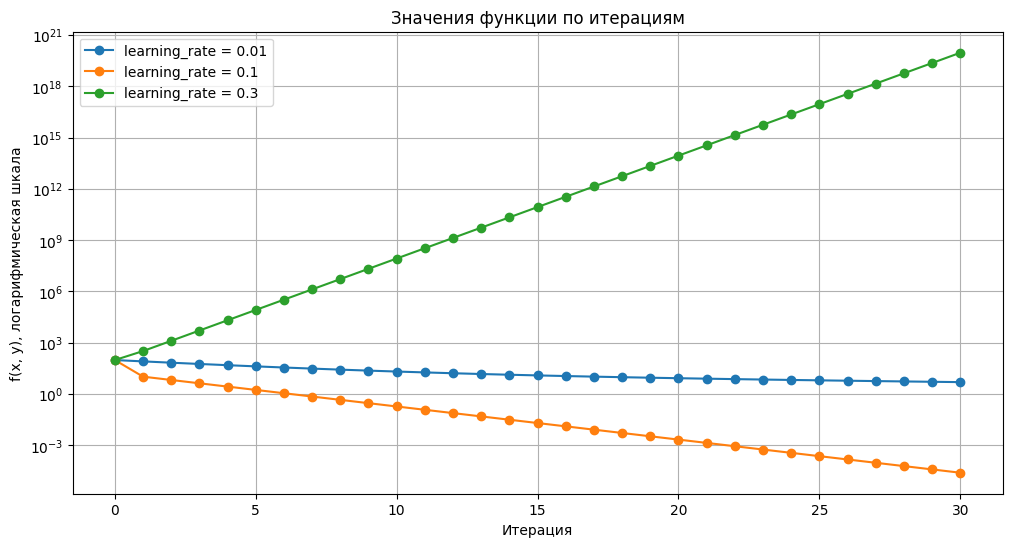

In [ ]:
# график значения функции по итерациям
plt.figure(figsize=(12,6))

for rate in learning_rates:
    plt.plot(
        results[rate]['loss_history'],
        marker='o',
        label=f'learning_rate = {rate}'
        )

plt.yscale('log')
plt.title('Значения функции по итерациям')
plt.xlabel('Итерация')
plt.ylabel('f(x, y), логарифмическая шкала')
plt.legend()
plt.grid(True)
plt.show()

*Для шага 0.3 будет показано только начало траектории. Если указать всю траекторию, при выводе графика линии уровня "сожмутся", визуализация будет непрезентативной.*

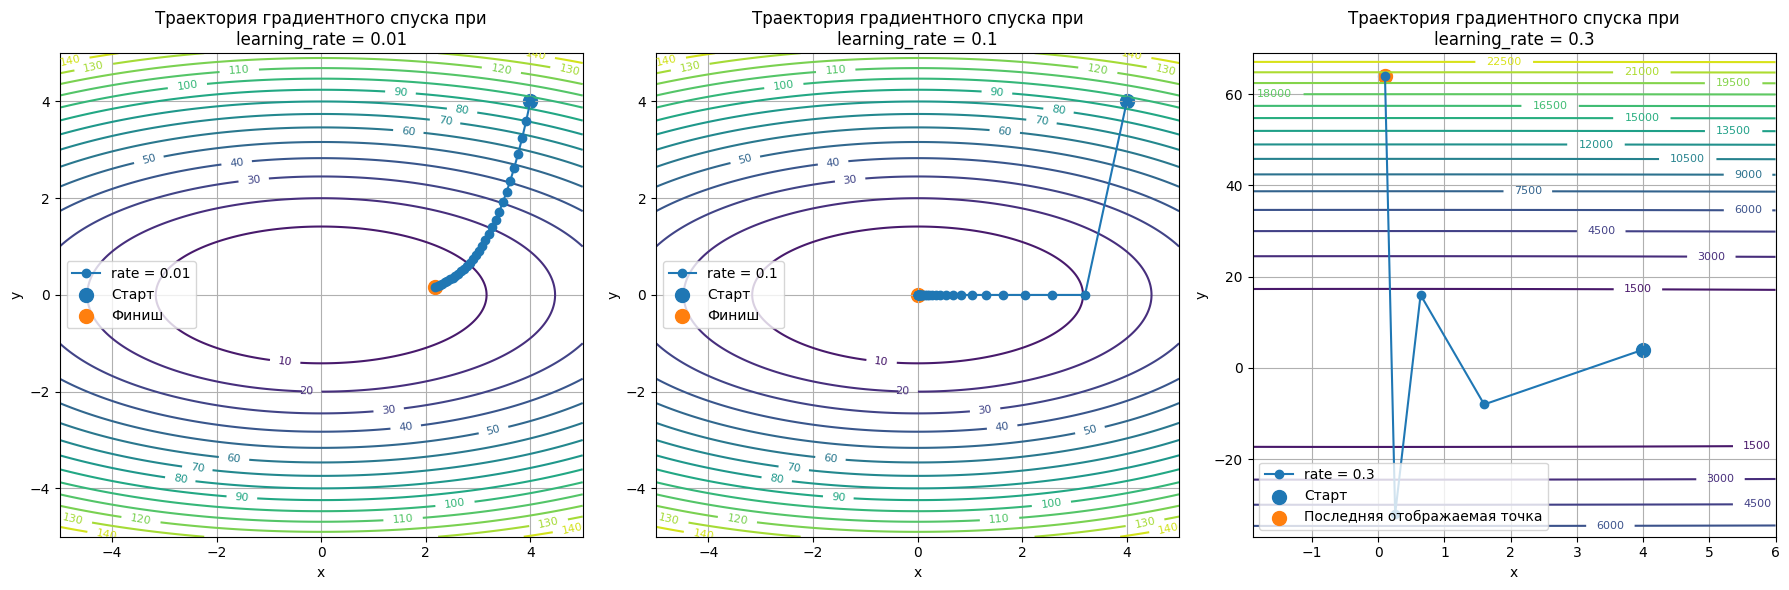

In [ ]:
# линии уровня и траектории движения алгоритма (градиентного спуска)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, rate in zip(axes, learning_rates):
    trajectory = results[rate]['trajectory']

    # для расходящегося случая (rate = 0.3) показываем только начало траектории
    if rate == 0.3:
        trajectory_plot = trajectory[:5]

        x_min = trajectory_plot[:, 0].min() - 2
        x_max = trajectory_plot[:, 0].max() + 2
        y_min = trajectory_plot[:, 1].min() - 5
        y_max = trajectory_plot[:, 1].max() + 5
    else:
        trajectory_plot = trajectory

        x_min, x_max = -5, 5
        y_min, y_max = -5, 5

    # сетка для линий уровня
    x_vals = np.linspace(x_min, x_max, 400)
    y_vals = np.linspace(y_min, y_max, 400)

    X, Y = np.meshgrid(x_vals, y_vals)
    Z = X**2 + 5 * Y**2

    # линии уровня
    contour = ax.contour(X, Y, Z, levels=15)
    ax.clabel(contour, inline=True, fontsize=8)

    # траектория
    ax.plot(
        trajectory_plot[:, 0],
        trajectory_plot[:, 1],
        marker='o',
        label=f'rate = {rate}'
    )

    # стартовая точка
    ax.scatter(
        trajectory_plot[0, 0],
        trajectory_plot[0, 1],
        s=100,
        label='Старт'
    )

    # последняя отображаемая точка
    ax.scatter(
        trajectory_plot[-1, 0],
        trajectory_plot[-1, 1],
        s=100,
        label='Последняя отображаемая точка'
        if rate == 0.3 else 'Финиш'
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.set_title(
        f'Траектория градиентного спуска при\n'
        f'learning_rate = {rate}'
    )

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

При `learning_rate = 0.01` градиентный спуск сходится очень медленно: после 30 итераций значение функции остаётся заметно выше минимума. При `learning_rate = 0.1` сходимость значительно быстрее, и алгоритм практически достигает точки минимума `(0, 0)`. При `learning_rate = 0.3` шаг оказывается слишком большим: траектория начинает перескакивать через минимум, значения координат растут по модулю, а функция расходится. Таким образом, слишком маленький `learning rate` замедляет обучение, а слишком большой может привести к расходимости; для данной функции наиболее удачным из рассмотренных значений оказался `0.1`

### 3. Сравнение полного градиентного спуска и SGD на задаче линейной регрессии

Используйте датасет:
* `make_regression(n_samples=300, n_features=1, noise=15, random_state=42)`

Что нужно сделать

* Сгенерировать датасет.
* Разделить данные на train и test.
* Реализовать обучение линейной регрессии двумя способами:
    * полный градиентный спуск;
    * стохастический градиентный спуск (SGD).
* Для обоих методов:
    * зафиксировать значения loss по итерациям;
    * сравнить скорость уменьшения loss;
    * сравнить стабильность обучения.
* Построить графики и кратко объяснить различия.

In [ ]:
# генерация данных
X, y = make_regression(n_samples=300, n_features=1, noise=15, random_state=42)

# разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

# преобразование Х в одномерные массивы для ручных вычислений
X_train = X_train.ravel()
X_test = X_test.ravel()

In [ ]:
# функции предсказания, потерь и градиентов
def predict(X, w, b):
    '''Вычисляет предсказание модели линейной регрессии'''
    return w * X + b

def mse_loss(y_true, y_pred):
    '''Вычисляет MSE'''
    return np.mean((y_true - y_pred) ** 2)

def gradients(X, y_true, y_pred):
    '''Вычисляет градиенты модели линейной регрессии'''
    n = len(y_true)

    dw = (2 / n) * np.sum((y_pred - y_true) * X)
    db = (2 / n) * np.sum(y_pred - y_true)

    return dw, db

In [ ]:
# реализация полного градиентного спуска (full GD)
def full_gradient_descent(X, y, learning_rate=0.01, n_epochs=100):
    '''Обучает линейную регрессию методом полного градиентного спуска'''
    # начальные значения параметров регрессии
    w = 0.0
    b = 0.0

    # история значений функции потерь
    loss_history = []

    for _ in range(n_epochs):
        # предсказания на всей обучающей выборке
        y_pred = predict(X, w, b)

        # loss
        loss = mse_loss(y, y_pred)
        loss_history.append(loss)

        # градиенты
        dw, db = gradients(X, y, y_pred)

        # обновление параметров
        w -= learning_rate * dw
        b -= learning_rate * db

    return w, b, np.array(loss_history)

# вызов
w_fgd, b_fgd, loss_fgd = full_gradient_descent(
    X_train,
    y_train
    )

print('Результаты обучения линейной регрессии полным градиентным спуском:\n')
print(f'w = {w_fgd:.4f}')
print(f'b = {b_fgd:.4f}')
print(f'Конечное значение train loss = {loss_fgd[-1]:.4f}')

Результаты обучения линейной регрессии полным градиентным спуском:

w = 23.4060
b = 0.3194
Конечное значение train loss = 245.9614


In [ ]:
# реализация стохастического градиентного спуска (SGD)
def stochastic_gradient_descent(X, y, learning_rate=0.01, n_epochs=100):
    '''Обучает линейную регрессию методом стохастичекого градиентного спуска'''
    # начальные значения параметров регрессии
    w = 0.0
    b = 0.0

    # история значений функции потерь
    loss_history = []

    # генератор случайных чисел для воспроизводимого перемешивания
    rng = np.random.default_rng(42)

    for epoch in range(n_epochs):

        # случайный порядок индексов объектов на каждой эпохе
        indices = rng.permutation(len(X))
        for i in indices:
            # один объект
            X_i = X[i]
            y_i = y[i]

            # предсказаниe по одному объекту
            y_pred_i = predict(X_i, w, b)

            # градиенты по одному объекту
            dw = 2 * (y_pred_i - y_i) * X_i
            db = 2 * (y_pred_i - y_i)

            # обновление параметров
            w -= learning_rate * dw
            b -= learning_rate * db

        # предсказания по всей выборке после завершении эпохи
        y_pred_all = predict(X, w, b)

        # loss по всей выборке
        loss = mse_loss(y, y_pred_all)
        loss_history.append(loss)

    return w, b, np.array(loss_history)

# вызов
w_sgd, b_sgd, loss_sgd = stochastic_gradient_descent(
    X_train,
    y_train
    )

print('Результаты обучения линейной регрессии стохастическим градиентным спуском:\n')
print(f'w = {w_sgd:.4f}')
print(f'b = {b_sgd:.4f}')
print(f'Конечное значение train loss = {loss_sgd[-1]:.4f}')

Результаты обучения линейной регрессии стохастическим градиентным спуском:

w = 28.5401
b = 0.2615
Конечное значение train loss = 229.6498


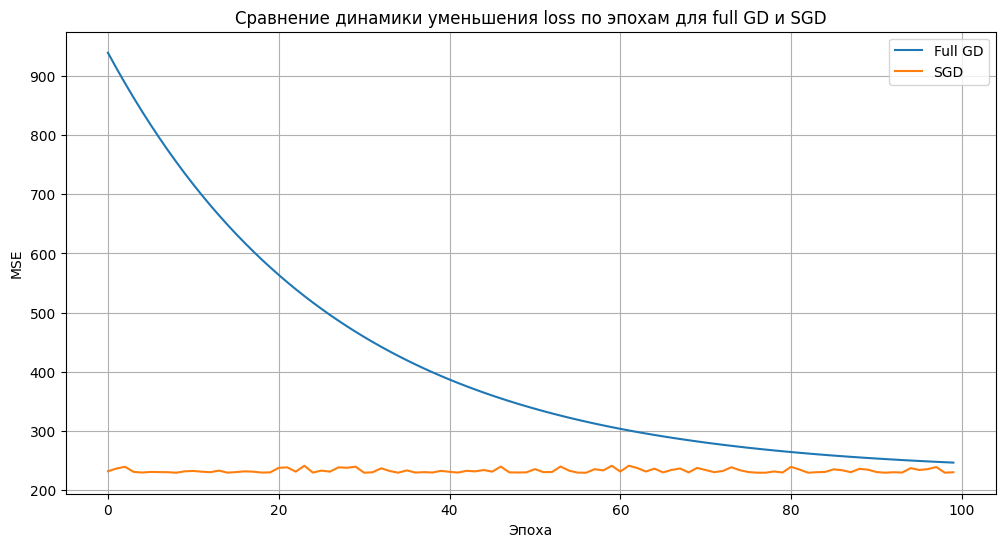

In [ ]:
# # сравнение динамики уменьшения loss по эпохам для Full GD и SGD
plt.figure(figsize=(12, 6))

plt.plot(loss_fgd, label='Full GD')
plt.plot(loss_sgd, label='SGD')

plt.title('Сравнение динамики уменьшения loss по эпохам для full GD и SGD')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

Полный градиентный спуск (`Full GD`) показывает плавное и стабильное уменьшение функции потерь, поскольку на каждой эпохе градиент вычисляется по всей обучающей выборке. `SGD` быстрее достигает низких значений `MSE` в пересчёте на число эпох, однако его `loss` заметно колеблется из-за обновления параметров по отдельным объектам. При этом сравнение по эпохам не позволяет однозначно утверждать, что `SGD` быстрее по времени или вычислительным затратам: за одну эпоху `Full GD` выполняет одно обновление параметров, а `SGD` — множество обновлений, по одному для каждого объекта. Поэтому по данному графику корректно сравнивать характер сходимости, но не фактическую вычислительную скорость.

### 4. Сравнение SGD и Adam на задаче бинарной классификации

Используйте датасет:
* `Breast Cancer` из `sklearn.datasets`

Что нужно сделать

* Загрузить датасет.
* Разделить данные на `train` и `test`.
* Выполнить масштабирование признаков.
* Обучить логистическую регрессию двумя оптимизаторами:
    * `SGD`
    * `Adam`
* Для каждого оптимизатора:
    * сохранить значения `loss` по эпохам;
    * оценить качество на тестовой выборке;
    * сравнить скорость обучения.

In [ ]:
# загрузка датасета
data = load_breast_cancer()

# признаки и целевая переменная
X = data.data
y = data.target

# разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

# масштабирование признаков
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# функции предсказания и потерь
def predict_log_regr(X, w, b):
    '''Вычисляет вероятности положительного класса (1)'''
    z = X @ w + b
    return 1 / (1 + np.exp(-z))

def bce_loss(y_true, y_pred):
    '''Вычисляет бинарную кросс-энтропию.'''
    # ограничение предсказанных вероятностей для избежания вычисления log(0).
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    return -np.mean(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )

In [ ]:
# реализация стохастического градиентного спуска (SGD)
def sgd_log_regr(X, y, learning_rate=0.01, n_epochs=100):
    '''Обучает логистическую регрессию методом стохастичекого градиентного спуска'''
    # начальные значения параметров регрессии
    w = np.zeros(X.shape[1])
    b = 0.0

    # история значений функции потерь
    loss_history = []

    # генератор случайных чисел для воспроизводимого перемешивания
    rng = np.random.default_rng(42)

    for epoch in range(n_epochs):

        # случайный порядок индексов объектов на каждой эпохе
        indices = rng.permutation(len(X))
        for i in indices:
            # один объект обучающей выборки
            X_i = X[i]
            y_i = y[i]

            # предсказаниe по одному объекту
            y_pred_i = predict_log_regr(X_i, w, b)

            # градиенты по одному объекту
            dw = (y_pred_i - y_i) * X_i
            db = y_pred_i - y_i

            # обновление параметров
            w -= learning_rate * dw
            b -= learning_rate * db

        # предсказания по всей выборке после завершении эпохи
        y_pred_all = predict_log_regr(X, w, b)

        # loss по всей выборке
        loss = bce_loss(y, y_pred_all)
        loss_history.append(loss)

    return w, b, np.array(loss_history)

# вызов
w_sgd_log_regr, b_sgd_log_regr, loss_sgd_log_regr = sgd_log_regr(
    X_train,
    y_train
    )

print('Результаты обучения логистической регрессии стохастическим градиентным спуском:\n')
print(f'w = {np.round(w_sgd_log_regr, 4)}')
print(f'b = {b_sgd_log_regr:.4f}')
print(f'Конечное значение train loss = {loss_sgd_log_regr[-1]:.4f}')

Результаты обучения логистической регрессии стохастическим градиентным спуском:

w = [-0.4885 -0.4798 -0.4366 -0.5752 -0.0946  0.7738 -0.9903 -1.3083  0.3759
  0.173  -1.6919  0.2183 -0.901  -1.2129 -0.4182  1.0275  0.1215 -0.3769
  0.6283  0.8443 -1.1267 -1.7052 -0.7901 -1.1103 -0.8109  0.0387 -1.2358
 -1.0806 -1.6267 -0.2024]
b = 0.3878
Конечное значение train loss = 0.0482


In [ ]:
# реализация Adam
def adam_log_regr(X, y, learning_rate=0.01, n_epochs=100):
    '''Обучает логистическую регрессию методом Adam'''
    # начальные значения параметров регрессии
    # вектор весов: по одному весу на каждый признак
    w = np.zeros(X.shape[1])
    # свободный член
    b = 0.0

    # первые моменты: накопленное сглаженное среднее градиентов
    m_w = np.zeros_like(w)
    m_b = 0.0

    # вторые моменты: накопленное сглаженное среднее квадратов градиентов
    v_w = np.zeros_like(w)
    v_b = 0.0

    # коэффициенты сглаживания первого и второго моментов
    beta1 = 0.9
    beta2 = 0.999

    # малое число для предотвращения деления на ноль
    epsilon = 1e-8

    # история значений функции потерь по эпохам
    loss_history = []

    # генератор случайных чисел для воспроизводимого перемешивания объектов
    rng = np.random.default_rng(42)

    # счетчик шагов Adam
    t = 0

    for epoch in range(n_epochs):

        # случайный порядок индексов объектов на каждой эпохе
        indices = rng.permutation(len(X))

        for i in indices:
            t += 1

            # один объект обучающей выборки
            X_i = X[i]
            y_i = y[i]

            # предсказаниe по одному объекту
            y_pred_i = predict_log_regr(X_i, w, b)

            # градиенты по одному объекту
            dw = (y_pred_i - y_i) * X_i
            db = y_pred_i - y_i

            # обновление параметров
            # первый момент — сглаженное среднее градиентов
            m_w = beta1 * m_w + (1 - beta1) * dw
            m_b = beta1 * m_b + (1 - beta1) * db

            # второй момент — сглаженное среднее квадратов градиентов
            v_w = beta2 * v_w + (1 - beta2) * (dw ** 2)
            v_b = beta2 * v_b + (1 - beta2) * (db ** 2)

            # коррекция смещения первого момента
            m_w_hat = m_w / (1 - beta1 ** t)
            m_b_hat = m_b / (1 - beta1 ** t)

            # коррекция смещения второго момента
            v_w_hat = v_w / (1 - beta2 ** t)
            v_b_hat = v_b / (1 - beta2 ** t)

            # обновление параметров модели
            w -= learning_rate * m_w_hat / (np.sqrt(v_w_hat) + epsilon)
            b -= learning_rate * m_b_hat / (np.sqrt(v_b_hat) + epsilon)

        # предсказания по всей выборке после завершении эпохи
        y_pred_all = predict_log_regr(X, w, b)

        # значение бинарной кросс-энтропии
        loss = bce_loss(y, y_pred_all)
        loss_history.append(loss)

    return w, b, np.array(loss_history)

# вызов
w_adam_log_regr, b_adam_log_regr, loss_adam_log_regr = adam_log_regr(
    X_train,
    y_train
    )

print('Результаты обучения логистической регрессии оптимизатором Adam:\n')
print(f'w = {np.round(w_adam_log_regr, 4)}')
print(f'b = {b_adam_log_regr:.4f}')
print(f'Конечное значение train loss = {loss_adam_log_regr[-1]:.4f}')

Результаты обучения логистической регрессии оптимизатором Adam:

w = [ 0.7057 -0.093   1.0139  1.0222  0.367   3.4485 -1.5475 -5.8545  1.2821
 -1.2581 -4.3525  0.7072  0.9099 -5.855  -1.2334  0.6484  1.7396 -1.1808
  1.8954  1.7025 -3.1231 -3.4197  0.2262 -3.3177  0.0793 -0.2661 -2.8487
 -0.9346 -3.6868  0.3261]
b = -1.1253
Конечное значение train loss = 0.0322


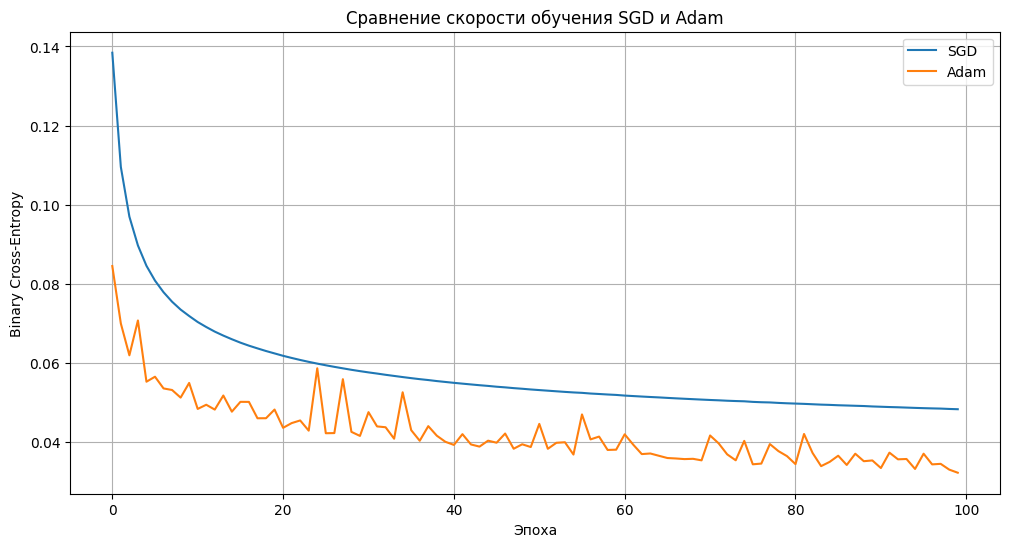

In [ ]:
# сравнение скорости обучения SGD и Adam
plt.figure(figsize=(12, 6))

plt.plot(loss_sgd_log_regr, label='SGD')
plt.plot(loss_adam_log_regr, label='Adam')

plt.title('Сравнение скорости обучения SGD и Adam')
plt.xlabel('Эпоха')
plt.ylabel('Binary Cross-Entropy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# оценка качества на тестовой выборке

# SGD
y_proba_sgd = predict_log_regr(X_test, w_sgd_log_regr, b_sgd_log_regr)
y_pred_sgd = (y_proba_sgd >= 0.5).astype(int)

# Adam
y_proba_adam = predict_log_regr(X_test, w_adam_log_regr, b_adam_log_regr)
y_pred_adam = (y_proba_adam >= 0.5).astype(int)

# метрики качества
print('SGD:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_sgd):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred_sgd):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_sgd):.4f}')

print('\nAdam:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_adam):.4f}')
print(f'F1-score: {f1_score(y_test, y_pred_adam):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_adam):.4f}')

SGD:
Accuracy: 0.9825
F1-score: 0.9859
ROC-AUC: 0.9974

Adam:
Accuracy: 0.9649
F1-score: 0.9714
ROC-AUC: 0.9954


В данной задаче `Adam` быстрее уменьшает функцию потерь и достигает более низкого значения `train loss`, однако, как видно по графику, его обучение сопровождается заметными колебаниями. `SGD` сходится медленнее и более плавно, но при этом показывает немного лучшие метрики на тестовой выборке:
* `SGD`
    * `Accuracy = 0.9825`
    * `F1 = 0.9859`
    * `ROC-AUC = 0.9974`
* `Adam`
    * `Accuracy = 0.9649`
    * `F1 = 0.9714`
    * `ROC-AUC = 0.9954`

 То есть можем сказать, что более низкий `train loss` не обязательно означает лучшее качество обобщения на новых данных.

### 5. Итоговый вывод

Какой оптимизатор вы бы выбрали для следующих сценариев и почему?

* маленький датасет без сильного шума;
* большой датасет с шумными наблюдениями;
* задача, где обучение идёт нестабильно и нужно быстрее добиться хорошей сходимости.

*Для маленького датасета без сильного шума* я бы выбрал полный градиентный спуск (`Full GD`). На небольшой выборке вычисление градиента по всем объектам не будет слишком затратным, зато обновление параметров модели будет стабильным, менее шумным. Это дает плавное уменьшение функции потерь без сильных колебаний.

*Для большого датасета с шумными наблюдениями* предпочтительнее `SGD`. Он обновляет параметры по отдельным объектам и поэтому не требует на каждом шаге обрабатывать всю выборку целиком. Это делает обучение быстрее и менее затратным по вычислениям на больших объёмах данных. Из-за стохастичности `loss` может колебаться, но такой подход хорошо масштабируется и подходит для шумных данных.

*Если обучение идёт нестабильно и нужно быстрее добиться хорошей сходимости*, лучше подойдет `Adam`. Он использует не только текущий градиент, но и накопленную информацию о направлении и величине прошлых градиентов. За счёт этого `Adam` адаптирует шаг обновления отдельно для разных параметров и часто быстрее достигает низких значений `loss`. В нашем эксперименте `Adam` действительно снижал бинарную кросс-энтропию быстрее и достиг меньшего `train loss`, хотя тот же `SGD` показал немного лучшие метрики на тестовой выборке.